Relação estado reuso: 
{2: 4, 3: 3, 4: 2, 5: 1}


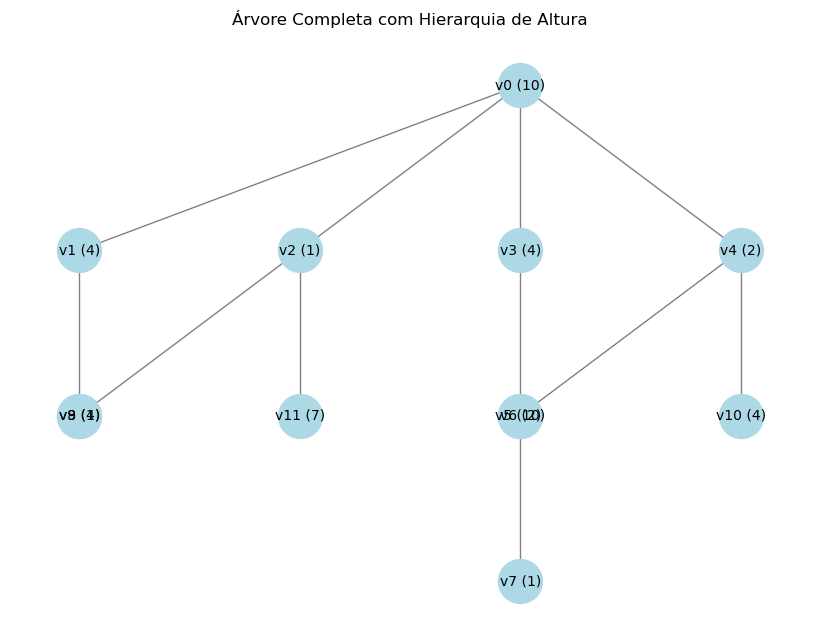


 ======== Estratégia Gulosa para Árvores ==========

Ana escolheu: ['v5', 'v3', 'v10', 'v7', 'v4', 'v1'] -> Ganho total: 25
Bob escolheu: ['v11', 'v9', 'v2', 'v6', 'v0', 'v8'] -> Ganho total: 25
Tempo de execução: 0.0 segundos
Iniciou às 2025-04-15 21:02:29.151

Com Programação Dinâmica :
Melhor caminho: ['v5', 'v11', 'v3', 'v7', 'v6', 'v9', 'v8', 'v1', 'v10', 'v2', 'v0', 'v4']
Tempo de execução: 4.034055709838867 segundos
Quantidade de estados  a serem gerados: 325
Número de entradas na tabela dinâmica: 325
Tamanho total do memo (real): 94928 bytes
Número de reusos: 1513
Número de estados distintos usados:  453

Vértices escolhidos por Ana: ['v5', 'v3', 'v6', 'v8', 'v10', 'v0']
Ganho de Ana: 31

Vértices escolhidos por Bob: ['v11', 'v7', 'v9', 'v1', 'v2', 'v4']
Ganho de Bob: 19

Estados Reutilizados:
('v0', 'v4') → reutilizado 8 vezes
Caminho percorrido: [('v5', 'v6', 'v7', 'v2', 'v9', 'v8', 'v1', 'v10', 'v11', 'v3'), ('v5', 'v6', 'v7', 'v2', 'v9', 'v8', 'v10', 'v3', 'v11', 'v1'), ('

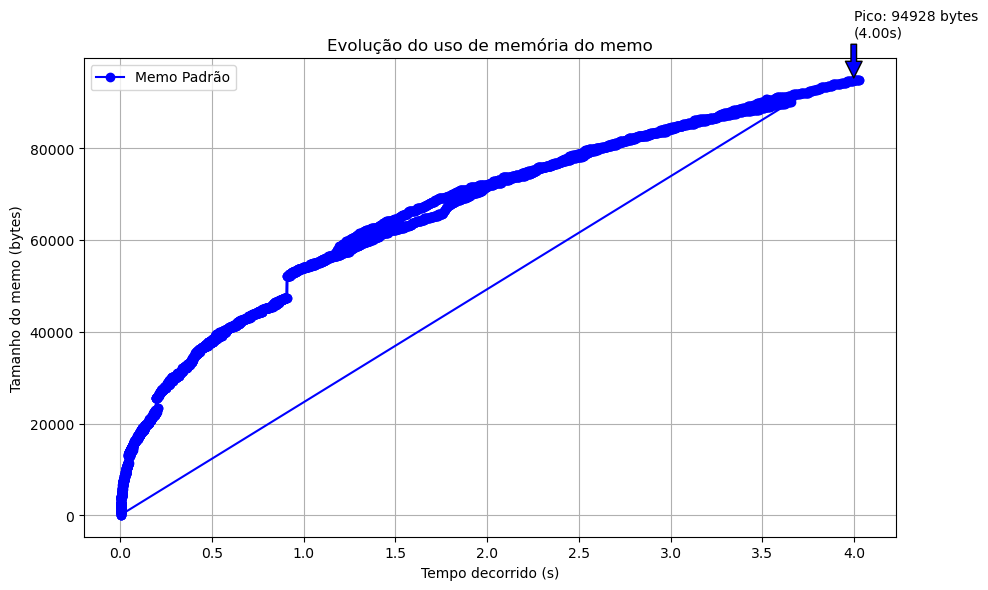

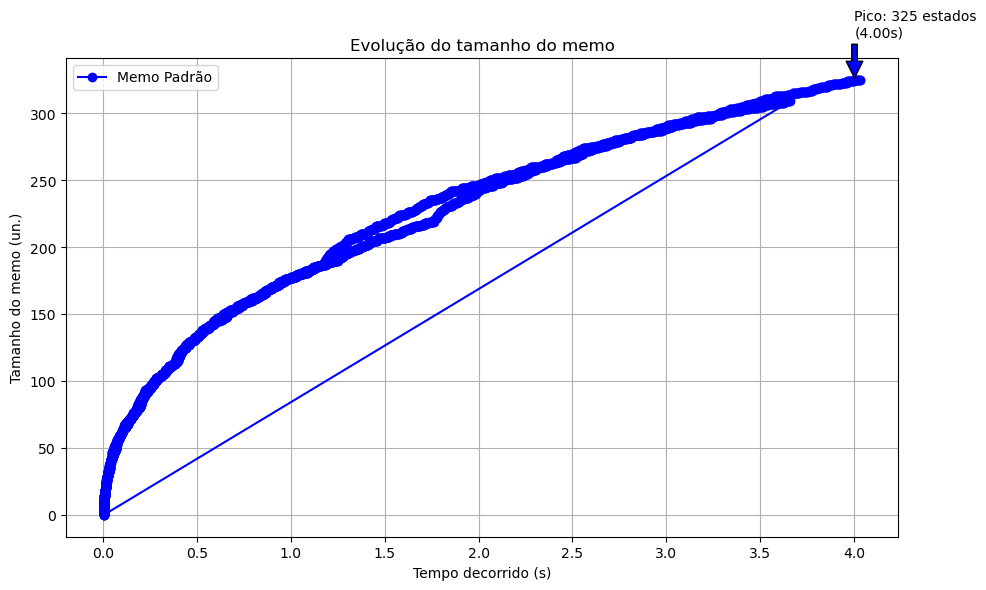

In [4]:
from geracao_grafos import *
from problemasPolinomiais.gulosoBicoloridoCiclo import *
from problemasPolinomiais.gulosoCompleto import *
from problemasPolinomiais.gulosoKmn import *
from problemasPolinomiais.gulosoArvore import *
from funcoesDP import *
from valG import *
from pympler import asizeof
#!pip install pympler

from otimizacoesPD.caminho_otimizado_pd import *
import gc
import sys


def mainSemDp(grafo, pesos):
    
    inicio_tempo = time.time()
    melhor_valor, arvore_decisao, melhor_caminho = valor(grafo, pesos)
    fim_tempo = time.time()
    print("Sem Programação Dinâmica:")
    print("Melhor caminho:", melhor_caminho)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    calcular_ganhos(melhor_caminho, pesos)
    imprimirArvoreDecisao(arvore_decisao,False)


def mainDP(grafo, pesos):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp(grafo, pesos, memo,inicio_tempo)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica :")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Tamanho total do memo (real):", asizeof.asizeof(memo), "bytes")
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    imprime_estados_reusados()
    imprime_estados_nao_reutilizados(memo)
    #imprime_tabela_dp(memo)

    return logs_memo,qtd_estados_plot
    #imprimirArvoreDecisao(arvore_decisao_dp)

def mainDP_Bipartido(grafo, pesos,m,n):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp_bipartido(grafo, pesos, memo,m,n,inicio_tempo)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica Kmn Otimizado:")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Tamanho total do memo (real):", asizeof.asizeof(memo), "bytes")
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    #imprime_estados_reusados()
    #imprime_estados_nao_reutilizados(memo)
    return logs_memoKmn,qtd_estados_plotKmn
    #imprime_tabela_dp(memo)
    #imprimirArvoreDecisao(arvore_decisao_dp)


def main():
    gc.collect()  # Força a coleta de lixo
    m, n = 3,4
    altura = 3
    gerar_reuso_estados(m, n)

    #grafo, pesos = grafoSimples()
    
    #grafo, pesos = gerar_grafo_ciclo(6)      # Gera um ciclo de 5 nós
    #grafo, pesos = gerar_grafo_completo(13)   # Gera um grafo completo de 6 nós
    #grafo, pesos = gerar_grafo_caminho(6)    # Gera um caminho de 4 nós
    
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido(m, n)
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido_completo(m, n)

    grafo, pesos = gerar_arvore_par(12)    
    #grafo, pesos = arvoreCompleta(altura)
    
    #mainGulosoKmn(grafo,pesos)
    mainGulosoArvore(grafo,pesos)

    mainDP( grafo, pesos)
    contagem_reuso_dp = []
    
    print("==================================================================================================")
    print("==================================================================================================")
    #mainDP_Bipartido(grafo,pesos,m,n)
    print("==================================================================================================")
    print("==================================================================================================")
    plotar_evolucao_memo(logs_memo,logs_memoKmn)
    plotar_evolucaoQtdEstados_memo(qtd_estados_plot,qtd_estados_plotKmn)
    #main_caminho_otimiziado_pd(grafo,pesos)

    #mainSemDp( grafo, pesos)
    #mainBicoloracaoCaminho( grafo, pesos)
    #mainGulosoCompleto(grafo,pesos)
    #mainGulosoBicoloridoCiclo(grafo,pesos)

if __name__ == "__main__":
    main()